<a href="https://colab.research.google.com/github/Katab-sawan/Dissertation/blob/XGBoost-Models/XGBNvda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_8291/569042023.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvda = yf.download('NVDA', start='2012-01-01', end=datetime.datetime.now())
[*********************100%***********************]  1 of 1 completed


Dataset shape: (3583, 5)
Price          Close      High       Low      Open     Volume
Ticker          NVDA      NVDA      NVDA      NVDA       NVDA
Date                                                         
2012-01-03  0.321791  0.330042  0.321104  0.327750  468044000
2012-01-04  0.325459  0.326834  0.319041  0.322021  347372000
2012-01-05  0.337148  0.338752  0.322479  0.323854  563548000
2012-01-06  0.333251  0.337148  0.329355  0.336918  533252000
2012-01-09  0.333251  0.339669  0.330959  0.333481  508244000
Training samples : 2508
Testing  samples : 1075
Model training complete.

    NVDA XGBoost Model Evaluation
  MAE  : $0.3709
  MSE  : $0.8603
  RMSE : $0.9275


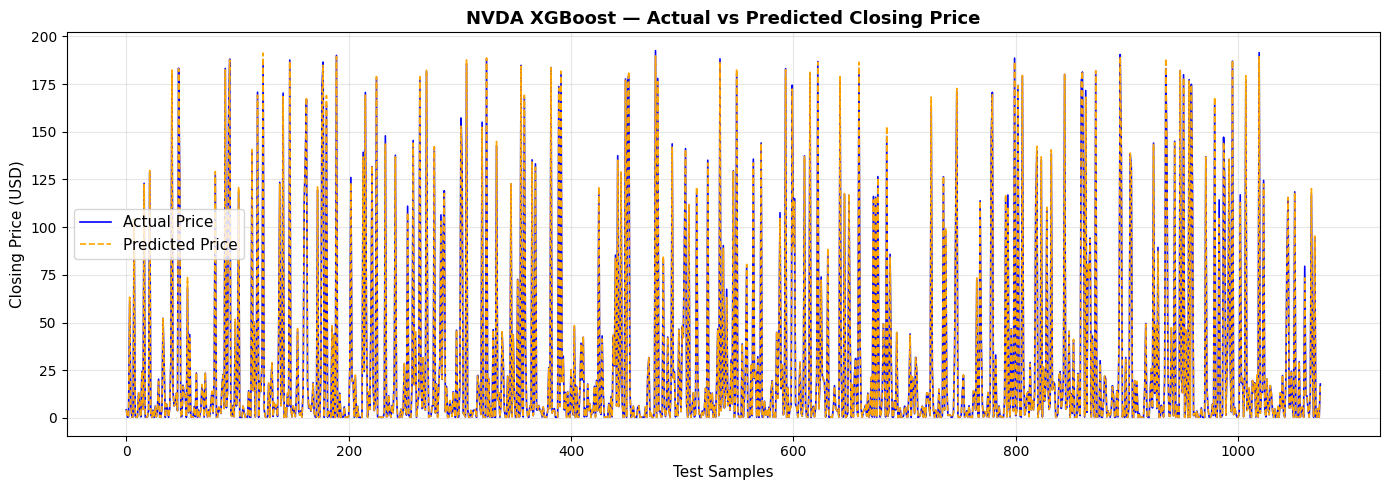

Figure saved: NVDA_xgboost_actual_vs_predicted.png


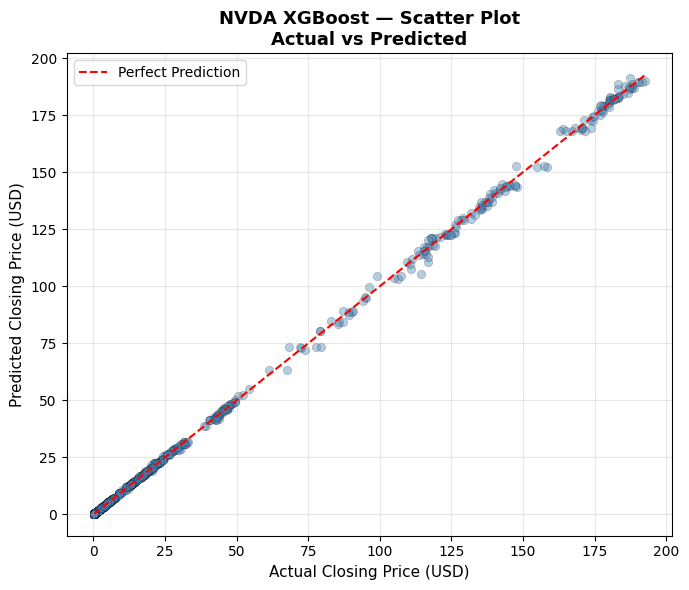

Figure saved: NVDA_xgboost_scatter.png


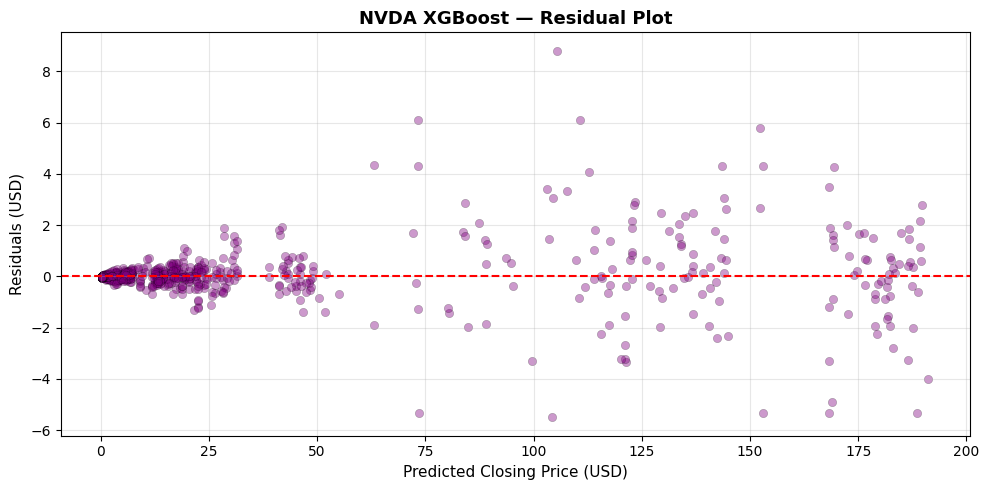

Figure saved: NVDA_xgboost_residuals.png

---------------------------------------------
      NVDA XGBoost — Results Summary
---------------------------------------------
  Stock           : NVIDIA (NVDA)
  Training Split  : 70%
  Testing  Split  : 30%
  Features        : Open, High, Low, Volume
  Target          : Close Price
---------------------------------------------
  MAE             : $0.3709
  MSE             : $0.8603
  RMSE            : $0.9275


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import yfinance as yf
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

nvda = yf.download('NVDA', start='2012-01-01', end=datetime.datetime.now())
nvda.dropna(inplace=True)
print(f"Dataset shape: {nvda.shape}")
print(nvda.head())

X = nvda[['Open', 'High', 'Low', 'Volume']].values
y = nvda['Close'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)
print("Model training complete.")

predictions = model.predict(X_test)

y_test_flat = np.array(y_test).flatten()
predictions = np.array(predictions).flatten()
min_len     = min(len(y_test_flat), len(predictions))
y_test_flat = y_test_flat[:min_len]
predictions = predictions[:min_len]

mae  = mean_absolute_error(y_test_flat, predictions)
mse  = mean_squared_error(y_test_flat, predictions)
rmse = np.sqrt(mse)

print("\n" + "="*45)
print("    NVDA XGBoost Model Evaluation")
print("="*45)
print(f"  MAE  : ${mae:.4f}")
print(f"  MSE  : ${mse:.4f}")
print(f"  RMSE : ${rmse:.4f}")
print("="*45)

plt.figure(figsize=(14, 5))
plt.plot(y_test_flat, color='blue', label='Actual Price', linewidth=1.2)
plt.plot(predictions, color='orange', label='Predicted Price',
         linewidth=1.2, linestyle='--')
plt.title('NVDA XGBoost — Actual vs Predicted Closing Price',
          fontsize=13, fontweight='bold')
plt.xlabel('Test Samples', fontsize=11)
plt.ylabel('Closing Price (USD)', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('NVDA_xgboost_actual_vs_predicted.png', dpi=150)
plt.show()
print("Figure saved: NVDA_xgboost_actual_vs_predicted.png")

plt.figure(figsize=(7, 6))
plt.scatter(y_test_flat, predictions, alpha=0.4, color='steelblue',
            edgecolors='k', linewidths=0.3)
plt.plot([y_test_flat.min(), y_test_flat.max()],
         [y_test_flat.min(), y_test_flat.max()],
         'r--', linewidth=1.5, label='Perfect Prediction')
plt.title('NVDA XGBoost — Scatter Plot\nActual vs Predicted',
          fontsize=13, fontweight='bold')
plt.xlabel('Actual Closing Price (USD)', fontsize=11)
plt.ylabel('Predicted Closing Price (USD)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('NVDA_xgboost_scatter.png', dpi=150)
plt.show()
print("Figure saved: NVDA_xgboost_scatter.png")

residuals = y_test_flat - predictions

plt.figure(figsize=(10, 5))
plt.scatter(predictions, residuals, alpha=0.4, color='purple',
            edgecolors='k', linewidths=0.3)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('NVDA XGBoost — Residual Plot', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Closing Price (USD)', fontsize=11)
plt.ylabel('Residuals (USD)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('NVDA_xgboost_residuals.png', dpi=150)
plt.show()
print("Figure saved: NVDA_xgboost_residuals.png")

print("\n" + "-"*45)
print("      NVDA XGBoost — Results Summary")
print("-"*45)
print(f"  Stock           : NVIDIA (NVDA)")
print(f"  Training Split  : 70%")
print(f"  Testing  Split  : 30%")
print(f"  Features        : Open, High, Low, Volume")
print(f"  Target          : Close Price")
print("-"*45)
print(f"  MAE             : ${mae:.4f}")
print(f"  MSE             : ${mse:.4f}")
print(f"  RMSE            : ${rmse:.4f}")
print("="*45)